(365,)
(322,)
(364,)
(365,)
(728,)
[-2.0786438  -1.7449646  -1.29144287 -1.04745483 -0.80804443 -1.12585449
 -3.03878784 -6.04168701 -5.45883179 -4.2203064  -3.25619507 -4.33969116
 -3.39611816 -2.25653076 -1.08532715 -0.49108887 -0.03430176 -0.03253174
 -0.01272583  0.13369751  2.00039673  4.29571533  4.58572388  4.79342651
  5.24563599  4.19219971  1.75131226  1.88781738  5.25848389  6.50253296]
[ 6.72769165e+00  8.38668823e+00  7.00955200e+00  3.42514038e+00
  2.25869751e+00  3.73773193e+00  4.00344849e+00  3.43884277e+00
  3.80441284e+00  2.91067505e+00  5.73181152e-01  5.79010010e-01
  4.56481934e-01 -8.14819336e-03 -3.11279297e-02 -3.14636230e-02
 -4.07409668e-02 -5.96618652e-02 -1.13922119e-01 -2.12982178e-01
 -4.25750732e-01 -7.62573242e-01 -7.15209961e-01 -6.36383057e-01
 -6.99737549e-01 -5.98175049e-01 -8.45367432e-01 -7.18994141e-01
 -9.38720703e-01 -7.60375977e-01]
DatetimeIndex(['2014-01-03', '2014-01-04', '2014-01-05', '2014-01-06',
               '2014-01-07', '2014-01-0

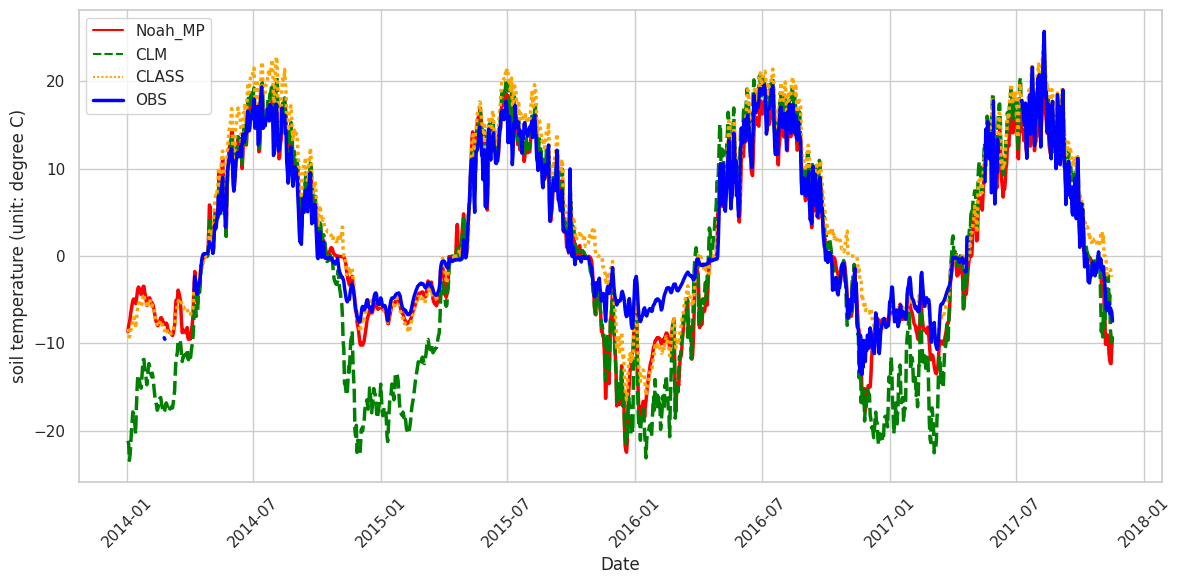

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import netCDF4 as nc
from pathlib import Path
import matplotlib.pyplot as plt

def load_soilliq_data_Noah_MP(filepath, filename):
    """
    Load soil liquid data from netCDF file.
    
    Parameters:
    -----------
    filepath : str
        Path to the directory containing the netCDF file
    filename : str
        Name of the netCDF file
    
    Returns:
    --------
    numpy.ndarray
        Processed soil liquid data
    """
    try:
        full_path = Path(filepath) / filename
        with nc.Dataset(full_path) as data:
            soilliq = data.variables['SOIL_T']
            # Convert to volumetric water content (divide by density and layer thickness)
            return soilliq[0:, 0,0, 0]-273.15
    except Exception as e:
        raise Exception(f"Error loading data from {full_path}: {str(e)}")
        
def load_soilliq_data_CLM(filepath, filename):
    """
    Load soil liquid data from netCDF file.
    
    Parameters:
    -----------
    filepath : str
        Path to the directory containing the netCDF file
    filename : str
        Name of the netCDF file
    
    Returns:
    --------
    numpy.ndarray
        Processed soil liquid data
    """
    try:
        full_path = Path(filepath) / filename
        with nc.Dataset(full_path) as data:
            soilliq = data.variables['TSOI']
            # Convert to volumetric water content (divide by density and layer thickness)
            return soilliq[0:, 2, 0]-273.15
    except Exception as e:
        raise Exception(f"Error loading data from {full_path}: {str(e)}")

def load_soilliq_data_CLASS(filepath, filename):
    """
    Load soil liquid data from netCDF file.
    
    Parameters:
    -----------
    filepath : str
        Path to the directory containing the netCDF file
    filename : str
        Name of the netCDF file
    
    Returns:
    --------
    numpy.ndarray
        Processed soil liquid data
    """
    try:
        full_path = Path(filepath) / filename
        with nc.Dataset(full_path) as data:
            soilliq = data.variables['tsl']
            # Convert to volumetric water content (divide by density and layer thickness)
            return soilliq[0:, 1,0, 0]-273.15
    except Exception as e:
        raise Exception(f"Error loading data from {full_path}: {str(e)}")


def load_csv_data(filepath, filename):
    """
    Load and process soil moisture data from CSV file.
    
    Parameters:
    -----------
    filepath : str
        Directory path containing the CSV file
    filename : str
        Name of the CSV file
    
    Returns:
    --------
    tuple
        (datetime_index, processed_soil_moisture_data)
    """
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path
    
    # Construct full file path
    full_path = Path(filepath) / filename
    
    try:
        # Read CSV file
        df = pd.read_excel(full_path)
        
        # Check if required column exists
        if 'tc_hum_10cm' not in df.columns:
            raise ValueError("Required column 'SoilMoist_hum_10cm' not found in CSV file")
        
        if 'DATE' not in df.columns:
            raise ValueError("Required column 'datetime' not found in CSV file")
        
        # Drop first row if it contains header information
        if not pd.api.types.is_numeric_dtype(df['tc_hum_10cm'].iloc[0]):
            df = df.drop(index=0).reset_index(drop=True)
        # Convert datetime column to proper datetime format
        df['DATE'] = pd.to_datetime(df['DATE'])
        
        # Set datetime as index properly
        df = df.set_index('DATE')
        
        # Extract soil moisture data
        obs_sm = df['tc_hum_10cm'].astype(float)
        
        # Calculate daily means (assuming 48 measurements per day)
        measurements_per_day = 48
        days = len(obs_sm) // measurements_per_day
        
        # Pre-allocate array for daily averages
        daily_means = np.full(days, np.nan)
        
        # Calculate daily averages more efficiently
        for i in range(days):
            slice_data = obs_sm[i*measurements_per_day:(i+1)*measurements_per_day]
            if not slice_data.empty and not slice_data.isna().all():
                daily_means[i] = slice_data.mean(skipna=True)
        print (df.index[0].date())
        # Create a datetime index for daily data
        daily_index = pd.date_range(
            start="2013-05-12",
            periods=days,
            freq='D'
        )
        
        return daily_index, daily_means
        
    except FileNotFoundError:
        print(f"Error: File not found at {full_path}")
        return None, None
    except Exception as e:
        print(f"Error processing data: {str(e)}")
        return None, None

# New function to calculate statistical metrics
def calculate_statistics(model_data, obs_data):
    """
    Calculate statistical metrics between model data and observations.
    
    Parameters:
    -----------
    model_data : numpy.ndarray or pd.Series
        Model simulated data
    obs_data : numpy.ndarray or pd.Series
        Observed data
    
    Returns:
    --------
    dict
        Dictionary containing various statistical metrics
    """
    # Convert inputs to numpy arrays if they aren't already
    model_array = np.array(model_data)
    obs_array = np.array(obs_data)
    
    # Check for NaN values and remove them
    mask = ~(np.isnan(model_array) | np.isnan(obs_array))
    model_clean = model_array[mask]
    obs_clean = obs_array[mask]
    
    # If no valid data points, return NaN for all metrics
    if len(model_clean) == 0:
        return {
            'RMSE': np.nan,
            'MAE': np.nan,
            'Bias': np.nan,
            'PBias': np.nan,
            'R': np.nan,
            'R2': np.nan,
            'NSE': np.nan,
            'N': 0
        }
    
    # Calculate metrics
    # Root Mean Square Error
    rmse = np.sqrt(np.mean((model_clean - obs_clean) ** 2))
    
    # Mean Absolute Error
    mae = np.mean(np.abs(model_clean - obs_clean))
    
    # Bias
    bias = np.mean(model_clean - obs_clean)
    
    # Percent Bias
    pbias = 100 * bias / np.mean(obs_clean) if np.mean(obs_clean) != 0 else np.nan
    
    # Correlation Coefficient
    # Check for constant values to avoid division by zero
    if np.std(model_clean) == 0 or np.std(obs_clean) == 0:
        r = np.nan
    else:
        r = np.corrcoef(model_clean, obs_clean)[0, 1]
    
    # Coefficient of determination (R-squared)
    r2 = r ** 2 if not np.isnan(r) else np.nan
    
    # Nash-Sutcliffe Efficiency
    nse_denominator = np.sum((obs_clean - np.mean(obs_clean)) ** 2)
    if nse_denominator == 0:
        nse = np.nan
    else:
        nse = 1 - (np.sum((model_clean - obs_clean) ** 2) / nse_denominator)
    
    # Return all metrics in a dictionary
    return {
        'RMSE': rmse,
        'MAE': mae,
        'Bias': bias,
        'PBias': pbias,
        'R': r,
        'R2': r2,
        'NSE': nse,
        'N': len(model_clean)
    }


# New function to create statistical matrix
def create_statistical_matrix(data_dict):
    """
    Create a statistical matrix comparing all models in the data_dict.
    
    Parameters:
    -----------
    data_dict : dict
        Dictionary with model names as keys and data arrays as values
        Should include 'OBS' for observations if available
    
    Returns:
    --------
    pandas.DataFrame
        DataFrame with all statistical metrics between models
    """
    models = list(data_dict.keys())
    
    # Initialize results dictionary
    results = {}
    
    # Calculate statistics for each model pair
    for i, model1 in enumerate(models):
        for j, model2 in enumerate(models):
            if i != j:  # Skip comparing model to itself
                stats = calculate_statistics(data_dict[model1], data_dict[model2])
                
                # Add to results with model pair as key
                results[f"{model1}_vs_{model2}"] = stats
    
    # Convert to DataFrame for easier viewing
    results_df = pd.DataFrame(results).T
    
    return results_df


def create_soil_moisture_comparison(data,date_obs,sm_obs, 
                                  start_date="2014-01-03", num_days=1415,
                                  rolling_window=None, save_path=None):
    """
    Create and optionally save a soil moisture comparison plot.
    
    Parameters:
    -----------
    ctl_path : str
        Path to control simulation directory
    ctl_file : str
        Control simulation filename
    lai_path : str
        Path to LAI simulation directory
    lai_file : str
        LAI simulation filename
    start_date : str
        Start date for the time series (default: "2014-01-01")
    num_days : int
        Number of days to plot (default: 365)
    rolling_window : int, optional
        Window size for rolling mean smoothing
    save_path : str, optional
        Path to save the figure
    
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure object
    """
    
    # Apply rolling mean if specified
    if rolling_window is not None:
        data = data.rolling(rolling_window).mean()
    # Create observation DataFrame - FIXED CODE HERE
    obs_data = None
    
    if dates_obs is not None and sm_obs is not None:
        # Convert start_date to pandas datetime
        start_date_pd = pd.to_datetime(start_date)
        end_date_pd = start_date_pd + pd.Timedelta(days=num_days-1)
        
        # Create a Series with the observation data
        obs_series = pd.Series(sm_obs, index=dates_obs)
        
        # Filter the series based on the date range
        obs_filtered = obs_series.loc[
            (obs_series.index >= start_date_pd) & 
            (obs_series.index <= end_date_pd)
        ]
        
        # If we have data, create a DataFrame
        if not obs_filtered.empty:
            obs_data = pd.DataFrame({"OBS": obs_filtered})
            
            # Apply same rolling window to observations if specified
            if rolling_window is not None:
                obs_data = obs_data.rolling(rolling_window, center=True).mean()
    
    # Create plot
    plt.figure(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    ax = sns.lineplot(data=data, palette=["red", "green","orange"], linewidth=2.5)
    #obs_data = None
    if obs_data is not None and not obs_data.empty:
        ax.plot(obs_data.index, obs_data['OBS'], color='blue', linewidth=2.5,label='OBS')
        ax.legend()
    # Customize plot
    #plt.title("10cm-Soil Temperature Comparison", fontsize=14, pad=15)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("soil temperature (unit: degree C)", fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Save if path provided
    #if save_path:
    plt.savefig('ST.png', dpi=300, bbox_inches='tight')
    # Calculate statistical metrics if observations are available
    stats_df = None
    if obs_data is not None and not obs_data.empty:
        # Create a dictionary with all data
        all_data = {
            "Noah_MP": data["Noah_MP"],
            "CLM": data["CLM"],
            "CLASS": data["CLASS"],
            "OBS": obs_data["OBS"]
        }
        
        # Calculate statistical matrix
        stats_df = create_statistical_matrix(all_data)
        
        # Print statistics for models vs observations
        print("\nStatistical metrics for each model compared to observations:")
        for model in ["Noah_MP", "CLM", "CLASS"]:
            stats = calculate_statistics(all_data[model], all_data["OBS"])
            print(f"\n{model} vs OBS:")
            for metric, value in stats.items():
                if isinstance(value, (float, int)):
                    print(f"  {metric}: {value:.4f}")
                else:
                    print(f"  {metric}: {value}")
    
    return plt.gcf(), stats_df
    


# [Previous functions remain the same until main]

if __name__ == "__main__":
    # Configuration
    BASE_PATH1 = Path("/glade/derecho/scratch/danqiongd/wetland_project/Noah-MP_output/intercomparison/sim/CA-SCB_protocol/Noahmp_out/")
    BASE_PATH2 = Path("/glade/derecho/scratch/danqiongd/wetland_project/Noah-MP_output/intercomparison/sim/CA-SCB_protocol/CLM_out/")
    #BASE_PATH2 = Path("/glade/derecho/scratch/danqiongd/archive/CAN-SCC/lnd/hist_default_snowthermal_hourly/daily_means/variables/")
    BASE_PATH4 = Path("/glade/derecho/scratch/danqiongd/wetland_project/Noah-MP_output/intercomparison/sim/CA-SCB_sens_sim/Vegfraction_sens/")
    BASE_PATH3 = Path("/glade/derecho/scratch/danqiongd/wetland_project/Noah-MP_output/intercomparison/sim/CA-SCB_protocol/CLASSIC_out/")
    PATHS = {
        'Noah_MP': BASE_PATH1,
        'CLM': BASE_PATH2,
        'CLASS': BASE_PATH3,
        'OBS': BASE_PATH4
    }
    
    # Define years and corresponding filenames
    year_file_mapping = {
        'Noah_MP':{2014: "2014_SOIL_T.nc",
        2015: "2015_SOIL_T.nc",
        2016: "2016_SOIL_T.nc",
        2017: "2017_SOIL_T.nc"
    },
        'CLM':{
        2014: "2170_TSOI.nc",
        2015: "2171_TSOI.nc",
        2016: "2172_TSOI.nc",
        2017: "2173_TSOI.nc"
    },
        'CLASS':{
        2014: "tsl_daily.nc",
        2015: "tsl_daily.nc",
        2016: "tsl_daily_2016.nc",
        2017: "tsl_daily_2016.nc"
    }
    }

    Obs_file = "TS_SCC_Danqiong.xlsx" #"can_scc.csv"
    # Loop through years
    Noah_data_1 = load_soilliq_data_Noah_MP (BASE_PATH1,year_file_mapping['Noah_MP'][2014])
    Noah_data_2 = load_soilliq_data_Noah_MP (BASE_PATH1,year_file_mapping['Noah_MP'][2015])
    Noah_data_3 = load_soilliq_data_Noah_MP (BASE_PATH1,year_file_mapping['Noah_MP'][2016])
    Noah_data_4 = load_soilliq_data_Noah_MP (BASE_PATH1,year_file_mapping['Noah_MP'][2017])
    Clm_data_1 = load_soilliq_data_CLM (BASE_PATH2,year_file_mapping['CLM'][2014])
    Clm_data_2 = load_soilliq_data_CLM (BASE_PATH2,year_file_mapping['CLM'][2015])
    Clm_data_3 = load_soilliq_data_CLM (BASE_PATH2,year_file_mapping['CLM'][2016])
    Clm_data_4 = load_soilliq_data_CLM (BASE_PATH2,year_file_mapping['CLM'][2017])
    Class_data_1 = load_soilliq_data_CLASS(BASE_PATH3,year_file_mapping['CLASS'][2014])
    Class_data_2 = load_soilliq_data_CLASS(BASE_PATH3,year_file_mapping['CLASS'][2016])
    print (Noah_data_3.shape)
    print (Noah_data_4.shape)
    print (Clm_data_3.shape)
    print (Clm_data_4.shape)
    print (Class_data_2.shape)
    #print (Class_data_2.shape)
    Class_data_values = np.zeros((1415))
    Clm_data_values = np.zeros((1415))
    Noah_data_values = np.zeros((1415))
    Class_data_values [0:362] = Class_data_1[2:364]
   # print (Class_data_1[2:364])
    Class_data_values [362] = np.nan
    Class_data_values [363:727]= Class_data_1[364:728]
    Class_data_values [727]= np.nan
    Class_data_values [728:1092] = Class_data_2[0:364]
    Class_data_values [1092] = np.nan
    Class_data_values [1093:1414] = Class_data_2[364:685]
    Class_data_values [1414] = np.nan
    Clm_data_values [0:363] = Clm_data_1[2::]
    Clm_data_values [363:728] = Clm_data_2[:]
    Clm_data_values [728:1092] = Clm_data_3[:]
    Clm_data_values [1092] = np.nan
    Clm_data_values [1093:1415] = Clm_data_4[0:322]
    Noah_data_values [0:363] = Noah_data_1[1::]
    Noah_data_values [363:728] = Noah_data_2[:]
    Noah_data_values [728:1093] = Noah_data_3[:]
    Noah_data_values [1093:1415] = Noah_data_4[:]
    print (Noah_data_values[1093+100:1093+130])
    print (Noah_data_values[1093+270:1093+300])
    start_date = "2014-01-03"

    dates = pd.date_range(start_date, periods=1093+118, freq="1D")
    print (dates)
    dates = pd.date_range(start_date, periods=1093+282, freq="1D")
    
    print (dates)
    #for year, filename in year_file_mapping.items(
    dates_obs, sm_obs = load_csv_data(BASE_PATH4,Obs_file)
    # Create dates and DataFrame
    start_date = "2014-01-03"
    dates = pd.date_range(start_date, periods=1415, freq="1D")
    data = pd.DataFrame({
        "Noah_MP": Noah_data_values[:],
        "CLM": Clm_data_values[:],
        "CLASS": Class_data_values[:]
    }, index=dates)
    print (dates_obs)
    fig,stats = create_soil_moisture_comparison(data,dates,sm_obs, 
                                  start_date="2014-01-03", num_days=1415,
                                  rolling_window=None, save_path=None)
    save_path=f'./10cm_Noah_MP_CLM_default_CLASS_soil_temperature_intercomparison_ens.png'
    if dates_obs is not None and sm_obs is not None:
        # Convert start_date to pandas datetime
        start_date_pd = pd.to_datetime(start_date)
        end_date_pd = start_date_pd + pd.Timedelta(days=1414)
        
        # Create a Series with the observation data
        obs_series = pd.Series(sm_obs, index=dates_obs)
        
        # Filter the series based on the date range
        obs_filtered = obs_series.loc[
            (obs_series.index >= start_date_pd) & 
            (obs_series.index <= end_date_pd)
        ]
    data = pd.DataFrame({
        "Noah_MP": Noah_data_values[:],
        "CLM": Clm_data_values[:],
        "CLASS": Class_data_values[:],
        "OBS": obs_filtered
    }, index=dates)
    
    data.to_csv('ST_data.csv', 
                          index=True,           # Include the index (dates)
                          index_label='Date',   # Column name for the index
                          float_format='%.6f',  # Format for floating point numbers (6 decimal places)
                          na_rep='NaN',         # How to represent NaN values
                          sep=',')              # Delimiter (comma by default)

    print("Data successfully exported to LE_data.csv")

    print ("stats:", stats)
        # Show the plot
    plt.show()
        
        # Close the figure to free up memory
    plt.close()